# Sentiment Analysis Pipeline
## Models: Naive Bayes & Logistic Regression | Features: BoW & TF-IDF
**Target Classes:** Positive, Negative, Neutral

## 1. Install & Import Dependencies

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import re

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 2. Load & Explore Data

In [ ]:


data = pd.read_csv("balanced_app_reviews.csv")

df = pd.DataFrame(data)

df = df[['app', 'content', 'translation', 'labelScore']]

df.tail()


print(f'Dataset shape: {df.shape}')
print(f'\nLabel distribution:')
print(df['labelScore'].value_counts())
df.head()

Dataset shape: (92474, 4)

Label distribution:
labelScore
Positive    33745
Negative    32175
Neutral     26554
Name: count, dtype: int64


,app,content,translation,labelScore
0,satusehat,"Aplikasi ribet ,udah di vaksin tp sertifikatny...","Complicated application, already vaccinated bu...",Negative
1,satusehat,kesalahan pemberian sertifikat yg seharusnya s...,Error granting a certificate that should be th...,Negative
2,satusehat,Terlalu sering mau d update,Too often want to update,Negative
3,satusehat,Tidak bisa di unduh,Can't be downloaded,Negative
4,satusehat,"Lambat , tidak update","Slow, not updated",Negative


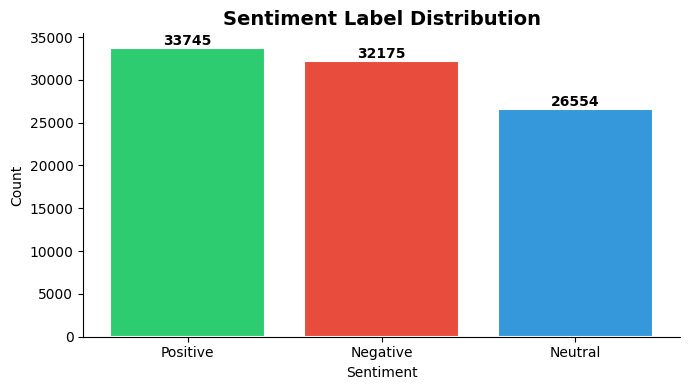

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
colors = {'Negative': '#e74c3c', 'Positive': '#2ecc71', 'Neutral': '#3498db'}
counts = df['labelScore'].value_counts()
bars = ax.bar(counts.index, counts.values,
              color=[colors.get(l, '#95a5a6') for l in counts.index],
              edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            str(val), ha='center', va='bottom', fontweight='bold')
ax.set_title('Sentiment Label Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Sentiment'); ax.set_ylabel('Count')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## 3. Text Preprocessing

In [ ]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text: str) -> str:
    """Full text cleaning pipeline."""
    if not isinstance(text, str):
        return ''
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove emails
    text = re.sub(r'\S+@\S+', '', text)
    # Remove special characters & digits
    text = re.sub(r'[^a-z\s]', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # Tokenize, remove stopwords, stem
    tokens = text.split()
    tokens = [stemmer.stem(t) for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

df['processed_text'] = df['translation'].apply(preprocess_text)

print('Sample preprocessing results:')
for i in range(3):
    print(f'\nOriginal : {df["translation"].iloc[i][:80]}')
    print(f'Processed: {df["processed_text"].iloc[i]}')

Sample preprocessing results:

Original : Complicated application, already vaccinated but the certificate isn't there, sev
Processed: complic applic alreadi vaccin certif isnt sever

Original : Error granting a certificate that should be the second certificate even on that 
Processed: error grant certif second certif even date instead first vaccin give send email instead consid sorri send complaint

Original : Too often want to update
Processed: often want updat


## 4. Feature Engineering — BoW & TF-IDF

In [ ]:
# Encode labels
le = LabelEncoder()
y = le.fit_transform(df['labelScore'])
X_text = df['processed_text']

print(f'Label encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}')

# Train/test split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)
print(f'\nTrain size: {len(X_train_raw)} | Test size: {len(X_test_raw)}')

#BoW
bow_vectorizer = CountVectorizer(
    ngram_range=(1, 2),   # unigrams + bigrams
    max_features=5000,
    min_df=1
)
X_train_bow = bow_vectorizer.fit_transform(X_train_raw)
X_test_bow  = bow_vectorizer.transform(X_test_raw)

#TF-IDF
tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=5000,
    min_df=1,
    sublinear_tf=True
)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_raw)
X_test_tfidf  = tfidf_vectorizer.transform(X_test_raw)

print(f'\nBoW  feature matrix: {X_train_bow.shape}')
print(f'TFIDF feature matrix: {X_train_tfidf.shape}')

Label encoding: {'Negative': np.int64(0), 'Neutral': np.int64(1), 'Positive': np.int64(2)}

Train size: 73979 | Test size: 18495

BoW  feature matrix: (73979, 5000)
TFIDF feature matrix: (73979, 5000)


## 5. Model Training

In [ ]:
models = {
    'Naive Bayes': MultinomialNB(alpha=1.0),
    'Logistic Regression': LogisticRegression(
        max_iter=1000, C=1.0,
        solver='lbfgs',
        random_state=42
    )
}

feature_sets = {
    'BoW':   (X_train_bow,   X_test_bow),
    'TF-IDF': (X_train_tfidf, X_test_tfidf)
}

results = {}   # store metrics
trained = {}   # store fitted models

for feat_name, (X_tr, X_te) in feature_sets.items():
    for model_name, model in models.items():
        key = f'{model_name} + {feat_name}'
        clf = model.__class__(**model.get_params())
        clf.fit(X_tr, y_train)
        y_pred = clf.predict(X_te)

        results[key] = {
            'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
            'F1 (macro)': round(f1_score(y_test, y_pred, average='macro', zero_division=0), 4),
            'Precision': round(precision_score(y_test, y_pred, average='macro', zero_division=0), 4),
            'Recall':    round(recall_score(y_test, y_pred, average='macro', zero_division=0), 4),
        }
        trained[key] = (clf, X_te, y_pred)
        print(f'✅ Trained: {key}')

results_df = pd.DataFrame(results).T
print('\n', results_df.to_string())

✅ Trained: Naive Bayes + BoW
✅ Trained: Logistic Regression + BoW
✅ Trained: Naive Bayes + TF-IDF
✅ Trained: Logistic Regression + TF-IDF

                               Accuracy  F1 (macro)  Precision  Recall
Naive Bayes + BoW               0.6212      0.5886     0.5935  0.5998
Logistic Regression + BoW       0.6152      0.5798     0.5838  0.5929
Naive Bayes + TF-IDF            0.6333      0.5923     0.6015  0.6091
Logistic Regression + TF-IDF    0.6294      0.5955     0.5988  0.6075


## 6. Evaluation

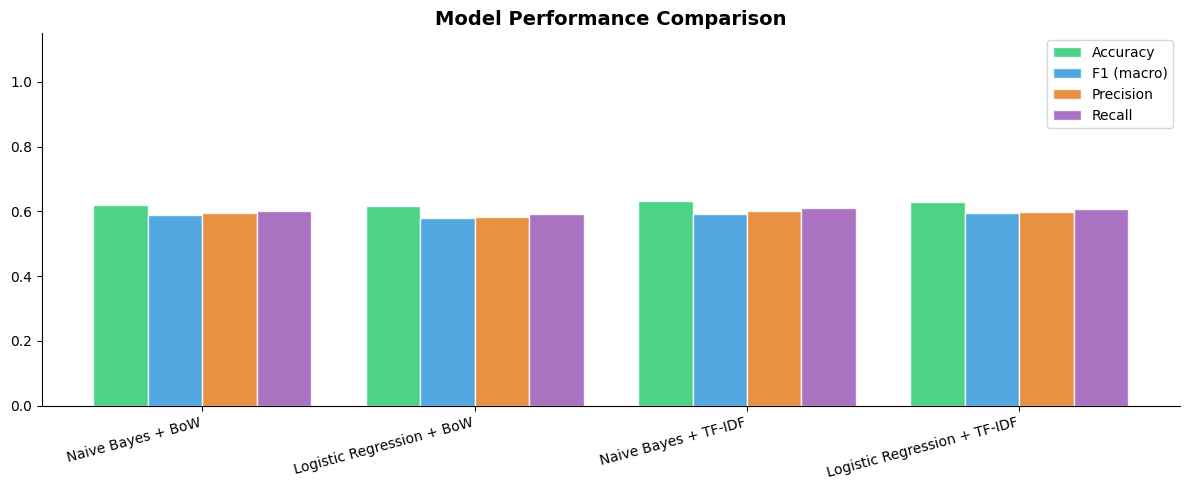

In [ ]:
# Metrics visualization
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(results_df))
width = 0.2
metrics = ['Accuracy', 'F1 (macro)', 'Precision', 'Recall']
palette = ['#2ecc71', '#3498db', '#e67e22', '#9b59b6']

for i, (metric, color) in enumerate(zip(metrics, palette)):
    bars = ax.bar(x + i*width, results_df[metric], width, label=metric,
                  color=color, alpha=0.85, edgecolor='white')

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df.index, rotation=15, ha='right')
ax.set_ylim(0, 1.15)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

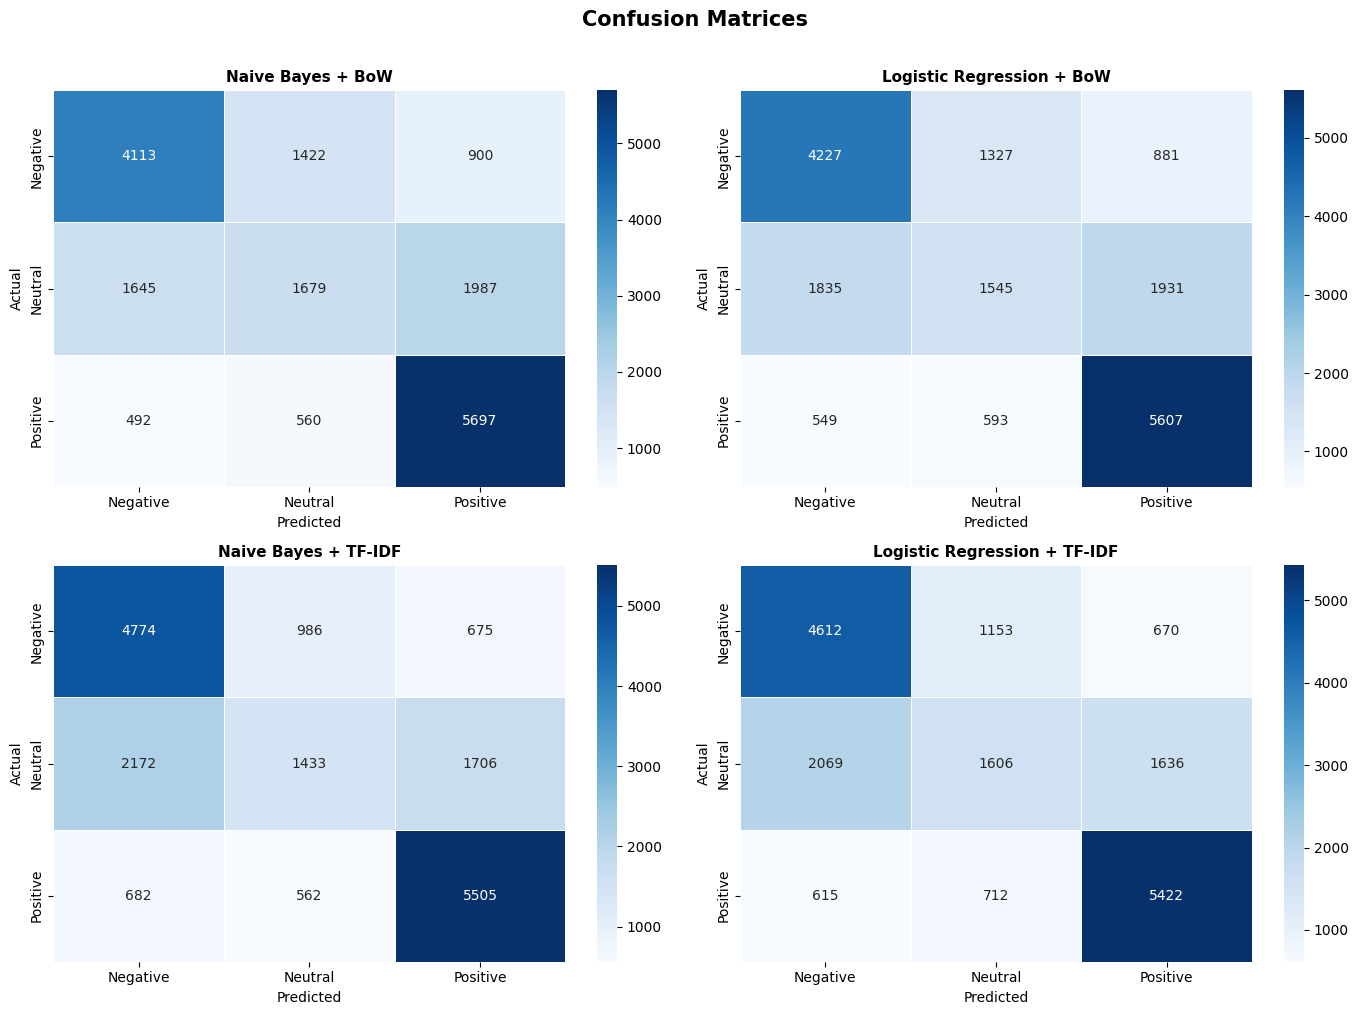

In [ ]:
#Confusion Matrix
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (key, (clf, X_te, y_pred)) in enumerate(trained.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_,
                ax=axes[idx], linewidths=0.5)
    axes[idx].set_title(key, fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Predicted'); axes[idx].set_ylabel('Actual')

plt.suptitle('Confusion Matrices', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

In [ ]:
#Classification Reports
for key, (clf, X_te, y_pred) in trained.items():
    print(f'\n{'='*60}')
    print(f'  {key}')
    print(f'{'='*60}')
    print(classification_report(y_test, y_pred,
                                 target_names=le.classes_,
                                 zero_division=0))


  Naive Bayes + BoW
              precision    recall  f1-score   support

    Negative       0.66      0.64      0.65      6435
     Neutral       0.46      0.32      0.37      5311
    Positive       0.66      0.84      0.74      6749

    accuracy                           0.62     18495
   macro avg       0.59      0.60      0.59     18495
weighted avg       0.60      0.62      0.60     18495


  Logistic Regression + BoW
              precision    recall  f1-score   support

    Negative       0.64      0.66      0.65      6435
     Neutral       0.45      0.29      0.35      5311
    Positive       0.67      0.83      0.74      6749

    accuracy                           0.62     18495
   macro avg       0.58      0.59      0.58     18495
weighted avg       0.59      0.62      0.60     18495


  Naive Bayes + TF-IDF
              precision    recall  f1-score   support

    Negative       0.63      0.74      0.68      6435
     Neutral       0.48      0.27      0.35      5311
 

In [ ]:
#Cross-Validation (5-fold Stratified)
print('5-Fold Stratified Cross-Validation (F1 Macro)\n')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for feat_name, (X_tr, X_te) in feature_sets.items():
    X_all = {
        'BoW':    bow_vectorizer.transform(X_text),
        'TF-IDF': tfidf_vectorizer.transform(X_text)
    }[feat_name]
    for model_name, model in models.items():
        clf = model.__class__(**model.get_params())
        scores = cross_val_score(clf, X_all, y, cv=cv,
                                  scoring='f1_macro', n_jobs=-1)
        print(f'{model_name} + {feat_name:6s}: '
              f'Mean={scores.mean():.4f}  Std={scores.std():.4f}')

5-Fold Stratified Cross-Validation (F1 Macro)

Naive Bayes + BoW   : Mean=0.5865  Std=0.0020
Logistic Regression + BoW   : Mean=0.5798  Std=0.0024
Naive Bayes + TF-IDF: Mean=0.5887  Std=0.0021
Logistic Regression + TF-IDF: Mean=0.5944  Std=0.0017


## 7. Top Features Analysis

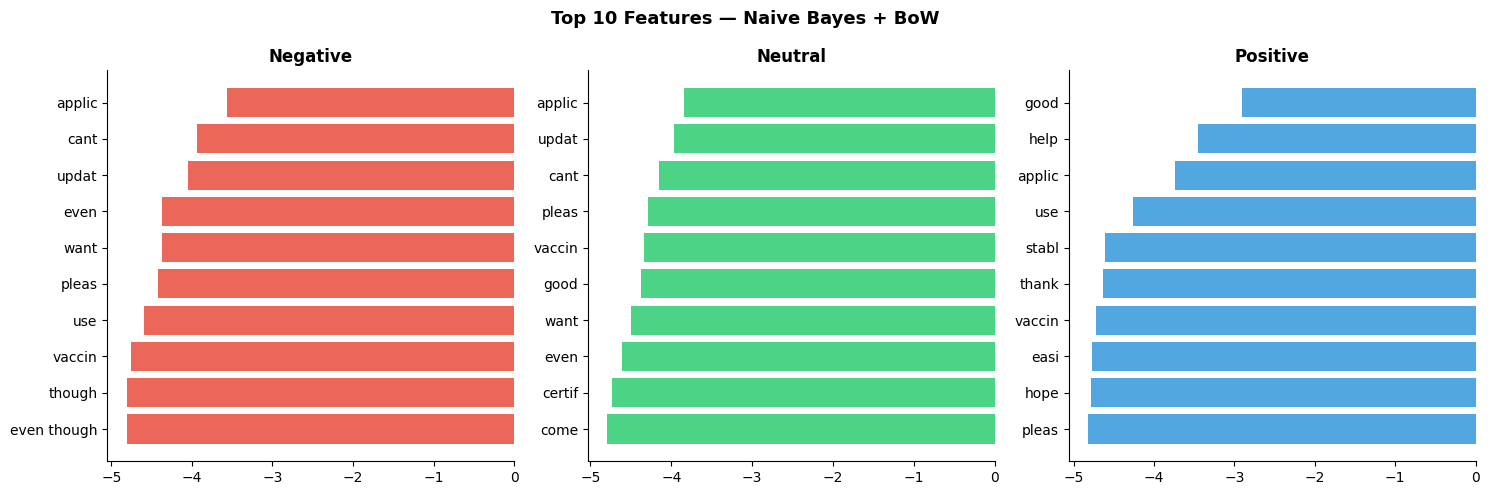

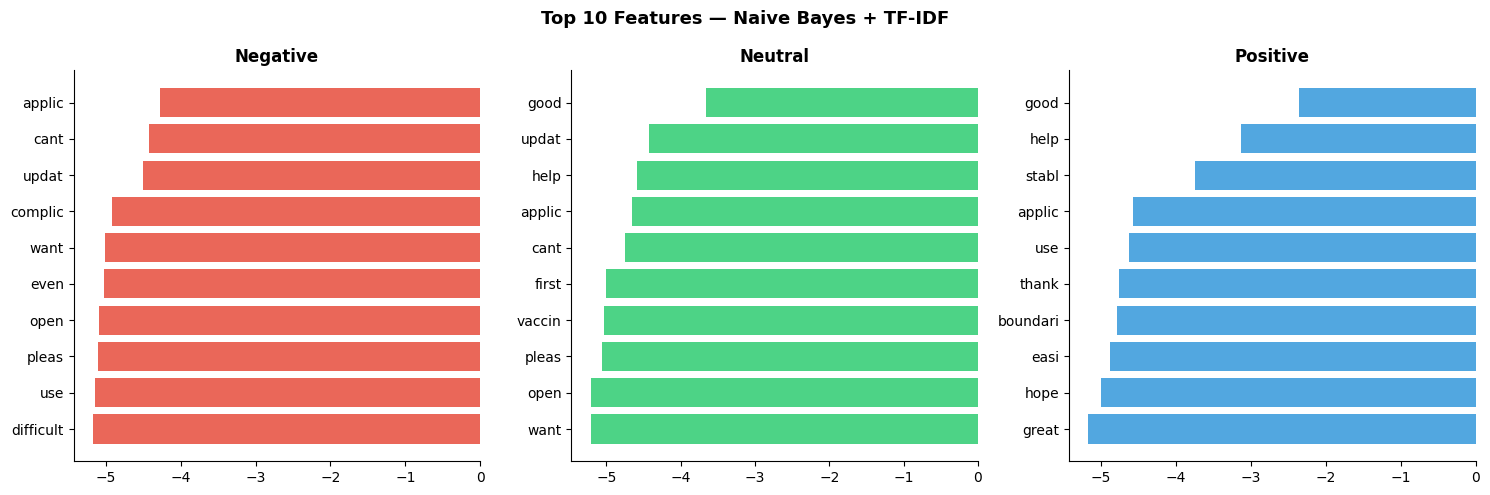

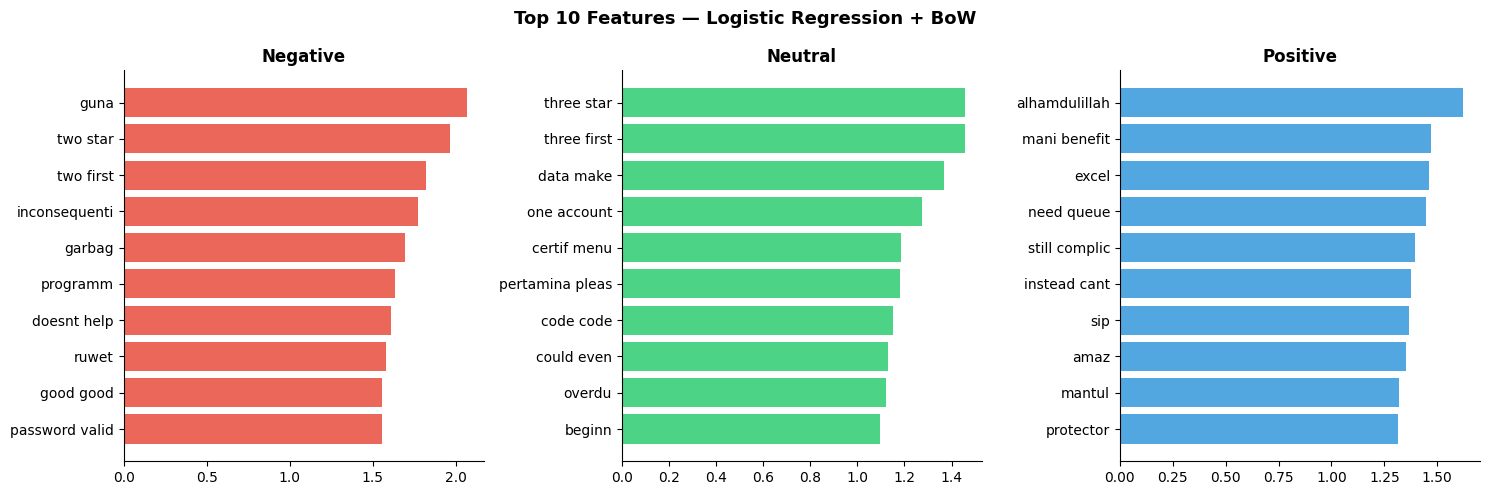

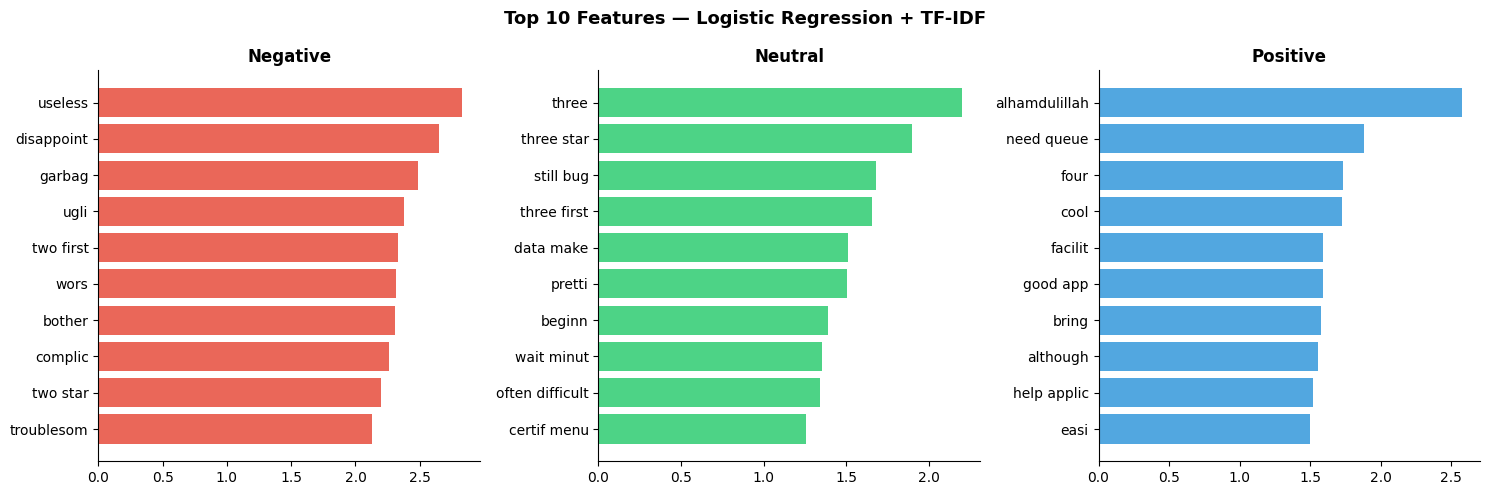

In [31]:
def plot_top_features(vectorizer, model, classes, feat_name, model_name, top_n=10):
    feature_names = np.array(vectorizer.get_feature_names_out())
    n_classes = len(classes)
    fig, axes = plt.subplots(1, n_classes, figsize=(5 * n_classes, 5))
    if n_classes == 1:
        axes = [axes]

    if hasattr(model, 'feature_log_prob_'):
        coef = model.feature_log_prob_
    elif hasattr(model, 'coef_'):
        coef = model.coef_
    else:
        print('Model does not expose feature weights.')
        return

    palette = ['#e74c3c', '#2ecc71', '#3498db']
    for i, (cls, ax) in enumerate(zip(classes, axes)):
        row = coef[i] if coef.shape[0] > 1 else coef[0]
        top_idx = np.argsort(row)[-top_n:][::-1]
        ax.barh(feature_names[top_idx][::-1], row[top_idx][::-1],
                color=palette[i % len(palette)], alpha=0.85)
        ax.set_title(f'{cls}', fontweight='bold')
        ax.spines[['top','right']].set_visible(False)

    fig.suptitle(f'Top {top_n} Features — {model_name} + {feat_name}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

# Plot for each combination
nb_bow   = trained['Naive Bayes + BoW'][0]
nb_tfidf = trained['Naive Bayes + TF-IDF'][0]
lr_bow   = trained['Logistic Regression + BoW'][0]
lr_tfidf = trained['Logistic Regression + TF-IDF'][0]

plot_top_features(bow_vectorizer,   nb_bow,   le.classes_, 'BoW',    'Naive Bayes')
plot_top_features(tfidf_vectorizer, nb_tfidf, le.classes_, 'TF-IDF', 'Naive Bayes')
plot_top_features(bow_vectorizer,   lr_bow,   le.classes_, 'BoW',    'Logistic Regression')
plot_top_features(tfidf_vectorizer, lr_tfidf, le.classes_, 'TF-IDF', 'Logistic Regression')

## 8. Export Models & Vectorizers

In [32]:
model_dir = 'streamlit/models'
os.makedirs(model_dir, exist_ok=True)

joblib.dump(bow_vectorizer,   f'{model_dir}/bow_vectorizer.pkl')
joblib.dump(tfidf_vectorizer, f'{model_dir}/tfidf_vectorizer.pkl')
joblib.dump(le,               f'{model_dir}/label_encoder.pkl')

export_map = {
    'nb_bow':   nb_bow,
    'nb_tfidf': nb_tfidf,
    'lr_bow':   lr_bow,
    'lr_tfidf': lr_tfidf,
}

for fname, clf in export_map.items():
    path = f'{model_dir}/{fname}.pkl'
    joblib.dump(clf, path)
    print(f'✅ Saved: {path}')

print(f'\n📦 All 4 models, 2 vectorizers, and 1 encoder exported to ./{model_dir}/')

✅ Saved: streamlit/models/nb_bow.pkl
✅ Saved: streamlit/models/nb_tfidf.pkl
✅ Saved: streamlit/models/lr_bow.pkl
✅ Saved: streamlit/models/lr_tfidf.pkl

📦 All 4 models, 2 vectorizers, and 1 encoder exported to ./streamlit/models/


## 9. Inference Pipeline

In [ ]:
def predict_sentiment(texts, model_path, vectorizer_path, encoder_path='models/label_encoder.pkl'):
    """
    Predict sentiment for a list of raw texts.

    Parameters
    ----------
    texts          : list[str]  — raw input texts
    model_path     : str        — path to saved .pkl model
    vectorizer_path: str        — path to saved vectorizer .pkl
    encoder_path   : str        — path to LabelEncoder .pkl

    Returns
    -------
    DataFrame with columns: text, predicted_label, probabilities
    """
    clf  = joblib.load(model_path)
    vec  = joblib.load(vectorizer_path)
    enc  = joblib.load(encoder_path)

    processed = [preprocess_text(t) for t in texts]
    X = vec.transform(processed)
    preds = clf.predict(X)
    labels = enc.inverse_transform(preds)

    proba = clf.predict_proba(X) if hasattr(clf, 'predict_proba') else None

    rows = []
    for i, (text, label) in enumerate(zip(texts, labels)):
        row = {'text': text, 'predicted': label}
        if proba is not None:
            for cls, p in zip(enc.classes_, proba[i]):
                row[f'prob_{cls}'] = round(p, 4)
        rows.append(row)
    return pd.DataFrame(rows)


#Demo predictions
test_sentences = [
    'This app is amazing and works perfectly every time',
    'Cannot download the application, very frustrated',
    'The app is okay, sometimes it works and sometimes it does not',
    'Excellent vaccine certificate, received immediately after vaccination',
    'System error keeps appearing, OTP never works',
]

print('=== Naive Bayes + TF-IDF ===')
display(predict_sentiment(test_sentences,
                           'models/nb_tfidf.pkl',
                           'models/tfidf_vectorizer.pkl'))

print('\n=== Logistic Regression + TF-IDF ===')
display(predict_sentiment(test_sentences,
                           'models/lr_tfidf.pkl',
                           'models/tfidf_vectorizer.pkl'))